In [17]:
# Cell 1: Import & config cơ bản

import sys
from pathlib import Path

import torch
import torch.nn.functional as F
from torchvision import transforms

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ===== ĐƯỜNG DẪN PROJECT GỐC (sửa nếu khác) =====
ROOT = Path("/")

# Thêm ROOT vào sys.path để import được model trong thư mục /model
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

print("➕ Added to sys.path:", ROOT)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Thiết bị:", device)


CLASS_NAMES = [
        "Banh beo", "Banh bot loc", "Banh can", "Banh canh", "Banh chung",
        "Banh cuon", "Banh duc", "Banh gio", "Banh khot", "Banh mi",
        "Banh pia", "Banh tet", "Banh trang nuong", "Banh xeo", "Bun bo Hue",
        "Bun dau mam tom", "Bun mam", "Bun rieu", "Bun thit nuong",
        "Ca kho to", "Canh chua", "Cao lau", "Chao long", "Com tam",
        "Goi cuon", "Hu tieu", "Mi quang", "Nem chua", "Pho",
        "Xoi xeo", "banh_da_lon", "banh_tieu", "banh_trung_thu",
    ]


➕ Added to sys.path: /
Thiết bị: cuda


In [18]:
# Cell 3: Load model EfficientNet + checkpoint mới nhất

import sys
from pathlib import Path
import torch

# 1) Lấy project root
ROOT = Path("/media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam")
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

print("✅ Added to sys.path:", ROOT)

# 2) Import model từ folder /model
from model.mtl_efficientnet_b0 import MTLEfficientNetB0

# 3) Khởi tạo model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 33
model = MTLEfficientNetB0(num_classes=num_classes)
model.to(device)

print("Thiết bị:", device)

# 4) Tìm checkpoint mtl_efficientnet_b0_best.pt trong các folder con của /Jupyter/runs
runs_dir = ROOT / "Jupyter" / "runs"
print("📁 runs_dir:", runs_dir)

# lấy tất cả file *best.pt
ckpt_list = sorted(runs_dir.rglob("*best.pt"))
print("\n🔍 Found checkpoints:")
for p in ckpt_list:
    print("  -", p)

if not ckpt_list:
    raise FileNotFoundError("❌ Không tìm thấy bất kỳ file '*best.pt' nào trong thư mục 'runs/'")

# => Lấy file checkpoint mới nhất
CKPT_PATH = ckpt_list[-1]
print("\n✅ Using checkpoint:", CKPT_PATH)

# 5) Load weight
ckpt = torch.load(CKPT_PATH, map_location=device)

# ---- CHỖ QUAN TRỌNG: bóc đúng state_dict của model ----
if "model_state_dict" in ckpt:
    state_dict = ckpt["model_state_dict"]
elif "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
else:
    # Trường hợp bạn save thẳng model.state_dict(...)
    state_dict = ckpt

# Nếu trong state_dict có prefix kiểu "model." thì bỏ đi
from collections import OrderedDict
clean_state_dict = OrderedDict()
for k, v in state_dict.items():
    new_k = k
    if new_k.startswith("model."):
        new_k = new_k[len("model."):]
    clean_state_dict[new_k] = v

# Load vào model (strict=False để bỏ qua key thừa/thiếu nhẹ)
missing, unexpected = model.load_state_dict(clean_state_dict, strict=False)

print("\n🔁 load_state_dict done.")
print("   Missing keys:", missing)
print("   Unexpected keys:", unexpected)

model.eval()
print("\n✅ Model loaded & set to eval().")


✅ Added to sys.path: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam
Thiết bị: cuda
📁 runs_dir: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs

🔍 Found checkpoints:
  - /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_01/checkpoints/mtl_effcientnet_b0_best.pt
  - /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_20251113-101729/checkpoints/mtl_effcientnet_b0_best.pt
  - /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_20251113-181112/checkpoints/mtl_effcientnet_b0_best.pt

✅ Using checkpoint: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_20251113-181112/checkpoints/mtl_effcientnet_b0_best.pt

🔁 load_state_dict done.
   Missing keys: ['backbone.features.0.0.weight', 'backbone.features.0.1.weight', 'backbone.features.0.1.bias', 'backbone.features.0.1.running_mean', 'backbone.features.0.1.running_var', 'ba

In [19]:
# Cell 3: Hàm preprocess + predict 1 patch ảnh

# THAM SỐ TIỀN XỬ LÝ – nên khớp với lúc train
IMG_SIZE = 224      # nếu lúc train bạn resize 224x224, sửa cho đúng
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def predict_patch(pil_patch):
    """
    Dự đoán 1 patch ảnh (PIL.Image) -> (label, prob, cls_idx)
    """
    x = preprocess(pil_patch).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)[0].cpu().numpy()

    cls_idx = int(np.argmax(probs))
    prob = float(probs[cls_idx])
    label = CLASS_NAMES[cls_idx]
    return label, prob, cls_idx


In [20]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def visualize_grid_detections(pil_img,
                              detections,
                              grid_rows,
                              grid_cols,
                              show_unknown=True,
                              figsize=(10, 8)):
    """
    Vẽ lưới + bounding box cho từng ô được model dự đoán.

    - Món biết: viền xanh lá, nét liền
    - Món không biết (UNKNOWN): viền cam, nét đứt
    """

    W, H = pil_img.size
    cell_w = W / grid_cols
    cell_h = H / grid_rows

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(pil_img)
    ax.set_axis_off()

    # Vẽ lưới mờ mờ cho dễ nhìn bố cục
    for r in range(1, grid_rows):
        y = r * cell_h
        ax.axhline(y, color="white", lw=1, alpha=0.6)
    for c in range(1, grid_cols):
        x = c * cell_w
        ax.axvline(x, color="white", lw=1, alpha=0.6)

    # Vẽ bounding box cho từng detection
    for det in detections:
        r = det["grid_row"]
        c = det["grid_col"]
        label = det["label"]
        prob  = det["prob"]

        is_unknown = (label == "UNKNOWN")

        # Tọa độ góc trái trên của ô
        x0 = c * cell_w
        y0 = r * cell_h

        rect = Rectangle(
            (x0, y0),
            cell_w,
            cell_h,
            linewidth=3,
            edgecolor="lime" if not is_unknown else "orange",
            linestyle="-" if not is_unknown else "--",
            facecolor="none"
        )
        ax.add_patch(rect)

        # Text hiển thị trên box
        if not is_unknown or show_unknown:
            if is_unknown:
                txt = f"Không rõ ({prob:.3f})"
            else:
                txt = f"{label} ({prob:.3f})"

            ax.text(
                x0 + 3,
                y0 + 15,
                txt,
                color="white",
                fontsize=8,
                ha="left",
                va="top",
                bbox=dict(boxstyle="round,pad=0.2",
                          facecolor="black",
                          alpha=0.6)
            )

    plt.tight_layout()
    plt.show()


In [21]:
# ===== Helpers cho phân tích bàn ăn =====

from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def summarize_table(detections):
    """
    In thống kê số ô có món / không có món / unknown.
    """
    total_cells = len(detections)
    known_cells = [d for d in detections if not d.get('is_unknown', False)]
    unknown_cells = [d for d in detections if d.get('is_unknown', False)]

    n_known = len(known_cells)
    n_unknown = len(unknown_cells)

    counter = Counter(d['label'] for d in known_cells)

    print(f"Tổng ô lưới: {total_cells}")
    print(f"  Ô có món (known): {n_known}")
    print(f"  Ô không rõ (unknown): {n_unknown}")
    print("  Thống kê theo món:")
    for label, cnt in counter.most_common():
        print(f"   - {label}: {cnt} ô")


def visualize_grid_detections(pil_img, detections, grid_rows, grid_cols):
    """
    Vẽ lưới + label từng ô. 
    - Ô 'unknown' tô màu / style khác cho dễ nhìn.
    """
    w, h = pil_img.size
    cell_w = w / grid_cols
    cell_h = h / grid_rows

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(pil_img)
    ax.set_title("Lưới món ăn trên bàn")
    ax.axis("off")

    # vẽ lưới
    for r in range(1, grid_rows):
        y = r * cell_h
        ax.axhline(y, color="yellow", linewidth=1, linestyle="--", alpha=0.7)

    for c in range(1, grid_cols):
        x = c * cell_w
        ax.axvline(x, color="yellow", linewidth=1, linestyle="--", alpha=0.7)

    # vẽ box + text từng ô
    for det in detections:
        r = det["grid_row"]
        c = det["grid_col"]
        label = det["label"]
        prob = det["prob"]
        is_unknown = det.get("is_unknown", False)

        x0 = c * cell_w
        y0 = r * cell_h

        # unknown: box cam đậm + chữ (UNKNOWN)
        if is_unknown:
            edgecolor = "orange"
            linestyle = ":"
            disp_label = f"{label} ? ({prob:.2f})"
        else:
            edgecolor = "red"
            linestyle = "-"
            disp_label = f"{label} ({prob:.2f})"

        rect = patches.Rectangle(
            (x0, y0),
            cell_w,
            cell_h,
            linewidth=2,
            edgecolor=edgecolor,
            facecolor="none",
            linestyle=linestyle,
        )
        ax.add_patch(rect)

        ax.text(
            x0 + 3,
            y0 + 15,
            disp_label,
            fontsize=8,
            color=edgecolor,
            bbox=dict(facecolor="black", alpha=0.3, edgecolor="none", pad=1),
        )

    plt.tight_layout()
    plt.show()


def find_food_positions(detections, target_label):
    """
    Trả về danh sách (r, c, prob) những ô có đúng món target_label
    và KHÔNG bị đánh dấu unknown.
    """
    found = []
    for det in detections:
        if det.get("is_unknown", False):
            # bỏ qua ô unknown
            continue
        if det["label"] == target_label:
            found.append((det["grid_row"], det["grid_col"], det["prob"]))
    return found


def visualize_one_food(pil_img, detections, target_label, grid_rows, grid_cols):
    """
    Vẽ lại ảnh chỉ highlight những ô chứa món target_label.
    """
    pos = find_food_positions(detections, target_label)
    if not pos:
        print(f"❌ Không tìm thấy món '{target_label}' trên bàn.")
        return

    print(f"✅ Tìm thấy {len(pos)} vị trí món '{target_label}' trên bàn:")

    w, h = pil_img.size
    cell_w = w / grid_cols
    cell_h = h / grid_rows

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(pil_img)
    ax.set_title(f"Vị trí món: {target_label}")
    ax.axis("off")

    for (r, c, prob) in pos:
        x0 = c * cell_w
        y0 = r * cell_h
        rect = patches.Rectangle(
            (x0, y0),
            cell_w,
            cell_h,
            linewidth=3,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            x0 + 3,
            y0 + 15,
            f"{target_label} ({prob:.2f})",
            fontsize=9,
            color="lime",
            bbox=dict(facecolor="black", alpha=0.3, edgecolor="none", pad=1),
        )

    plt.tight_layout()
    plt.show()


In [22]:
# ==== Cell: detect món trên bàn bằng lưới ====
import torch
import torchvision.transforms as T
import numpy as np

# Ngưỡng: thử thấp xuống để bớt bị UNKNOWN
CONF_THRES = 0.50   # thử 0.5 trước, sau tăng/giảm tùy kết quả

# Chuẩn hóa giống lúc train EfficientNet
transform = T.Compose([
    T.Resize((224, 224)),   # IMAGE_SIZE = 224 nếu bạn train 224x224
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def classify_patch(pil_patch):
    """
    Nhận 1 patch PIL -> trả (pred_label, max_prob, pred_idx, logits)
    """
    model.eval()
    with torch.no_grad():
        x = transform(pil_patch).unsqueeze(0).to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]
        max_prob, pred_idx = torch.max(probs, dim=0)
        max_prob = float(max_prob.cpu())
        pred_idx = int(pred_idx.cpu())
    label = CLASS_NAMES[pred_idx]
    return label, max_prob, pred_idx, probs.cpu().numpy()

def detect_foods_on_table(pil_img, grid_rows=3, grid_cols=3,
                          conf_thres=CONF_THRES, verbose=True):
    """
    Chia ảnh bàn ăn thành lưới, classify từng ô.
    Trả về list detections:
      {
        'grid_row': r,
        'grid_col': c,
        'label': label hoặc "UNKNOWN",
        'prob': max_prob,
        'is_unknown': bool
      }
    """
    w, h = pil_img.size
    cell_w = w / grid_cols
    cell_h = h / grid_rows

    detections = []

    for r in range(grid_rows):
        for c in range(grid_cols):
            left   = int(c * cell_w)
            top    = int(r * cell_h)
            right  = int((c+1) * cell_w)
            bottom = int((r+1) * cell_h)

            patch = pil_img.crop((left, top, right, bottom))
            label, max_prob, pred_idx, _ = classify_patch(patch)

            if max_prob < conf_thres:
                final_label = "UNKNOWN"
                is_unknown  = True
            else:
                final_label = label
                is_unknown  = False

            d = {
                "grid_row": r,
                "grid_col": c,
                "label": final_label,
                "prob":  max_prob,
                "is_unknown": is_unknown,
                "raw_label": label,         # label gốc dù có bị UNKNOWN
            }
            detections.append(d)

            if verbose:
                print(f"[r{r}, c{c}] {final_label:10s} | raw={label:15s} | prob={max_prob:.3f}")

    return detections


Ảnh: /home/mtl/Downloads/hhh.jpg
[r0, c0] UNKNOWN    | raw=Xoi xeo         | prob=0.041
[r0, c1] UNKNOWN    | raw=Xoi xeo         | prob=0.042
[r0, c2] UNKNOWN    | raw=Xoi xeo         | prob=0.035
[r1, c0] UNKNOWN    | raw=Goi cuon        | prob=0.038
[r1, c1] UNKNOWN    | raw=Xoi xeo         | prob=0.041
[r1, c2] UNKNOWN    | raw=Banh gio        | prob=0.038
[r2, c0] UNKNOWN    | raw=Xoi xeo         | prob=0.038
[r2, c1] UNKNOWN    | raw=Xoi xeo         | prob=0.036
[r2, c2] UNKNOWN    | raw=Xoi xeo         | prob=0.039
Tổng ô lưới: 9
  Ô có món (known): 0
  Ô không rõ (unknown): 9
  Thống kê theo món:


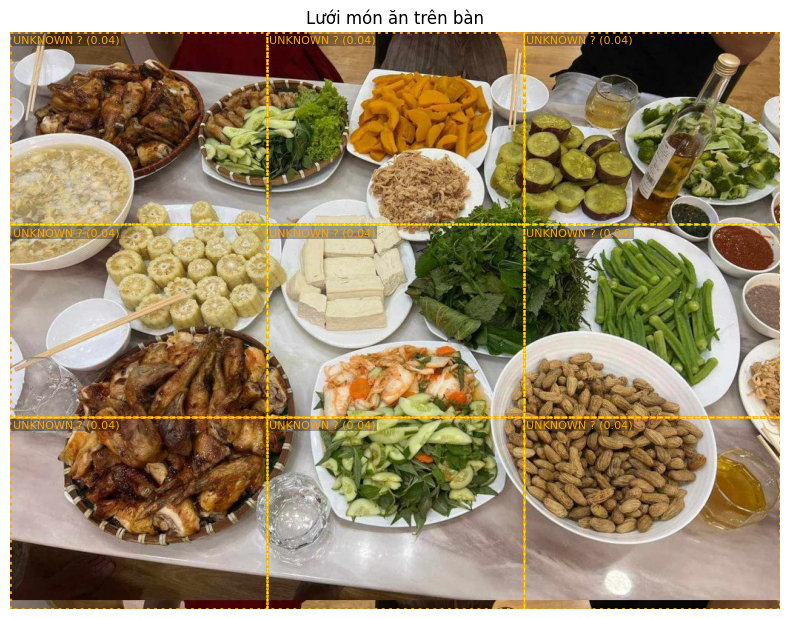

❌ Không tìm thấy món 'Hu tieu' trên bàn.


In [23]:
# Cell 7: Test trên 1 ảnh bàn ăn nhiều món

from pathlib import Path
from PIL import Image

# ĐƯỜNG DẪN ẢNH BÀN ĂN
#IMG_PATH = ROOT / "images" / "ban-an-example.jpg"
IMG_PATH = "/home/mtl/Downloads/hhh.jpg"   # sửa lại tên file

print("Ảnh:", IMG_PATH)
pil_img = Image.open(IMG_PATH).convert("RGB")      # <- đảm bảo pil_img là ảnh PIL

# Tham số lưới
GRID_ROWS = 3
GRID_COLS = 3

detections = detect_foods_on_table(pil_img, GRID_ROWS, GRID_COLS,
                                   conf_thres=0.5, verbose=True)

summarize_table(detections)
visualize_grid_detections(pil_img, detections, GRID_ROWS, GRID_COLS)


TARGET_LABEL = "Hu tieu"
found = find_food_positions(detections, TARGET_LABEL)

visualize_one_food(pil_img, detections, TARGET_LABEL,GRID_ROWS, GRID_COLS)
